In [1]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import trange
import os
import urllib
from tqdm import tqdm
from os import listdir
import pathlib
from torchvision.io import decode_image
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# If there is hardware acceleration use it

In [2]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


# How to read the data
* Reading the data
* Putting the image stright into ram is not a good idea
* I think maybe I will be using a CVS file that store the classification of the image and the path to the image. 

In [3]:
# https://www.geeksforgeeks.org/python-list-files-in-a-directory/
# https://stackoverflow.com/questions/3430372/how-do-i-get-the-full-path-of-the-current-files-directory
# https://stackoverflow.com/questions/431684/how-do-i-change-the-working-directory-in-python
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'train' in dir_list:
    train_dir_path = os.path.join(os.path.join(path,'train'),'train')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"" + os.path.join(path,'train') + "\"")

# Setting up transform for the image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [4]:
# transform = transforms.Compose()
# Define transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Import image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [5]:

dataset = datasets.ImageFolder(train_dir_path,transform=transform)

# Split dataset
* https://discuss.pytorch.org/t/how-to-split-dataset-into-test-and-validation-sets/33987

In [6]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9,0.1])

# Data loaders

In [7]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Image augmentation
* Adversarial attack (Suggested by Johnson)
* Flip
* Inverse
* Rotate
* Zoom

### Resourse on doing augmentation
* https://pytorch.org/vision/main/transforms.html

# Image augmentation function

In [8]:
def imageAugment(image):
    return image

# Learning transfer learning from exercise
* https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs?usp=sharing

In [9]:
import torchvision.models as models
base_model = models.vgg16(pretrained=True)

c:\Users\wthom\Documents\GitHub\CSE_144_Final_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\wthom\Documents\GitHub\CSE_144_Final_Project\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
class VGG16Head(nn.Module):
    def __init__(self, num_classes=100):
        super(VGG16Head, self).__init__()
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Setting up the nn
* This code is from https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs#scrollTo=3kTYygi258Yv

In [11]:
# Initialize the network and optimizer
base_model = models.vgg16(pretrained=True).to(device=device)
net = VGG16Head().to(device=device)
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Calculating the accuracy of the model

In [12]:
# Function to calculate accuracy
def calculate_accuracy(loader, model, base_model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in loader:
            images, labels = data
            with torch.no_grad():
              # The VGG is frozen
              vgg_features = base_model.features(images.to(device=device))
            outputs = net(vgg_features)
            _, predicted = torch.max(outputs.cpu().data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training

In [13]:
start_time = time.time()
# Training the network
num_epochs = 50
train_losses, test_losses = [], []
train_acc, test_acc = [], []

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        with torch.no_grad():
          # The VGG is frozen
          vgg_features = base_model.features(inputs.to(device=device))
        outputs = net(vgg_features)
        loss = criterion(outputs.cpu(), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_accuracy = calculate_accuracy(train_loader, net, base_model)
    train_acc.append(train_accuracy)

    test_loss = 0.0
    for data in test_loader:
        images, labels = data
        with torch.no_grad():
          # The VGG is frozen
          vgg_features = base_model.features(images.to(device=device))
        outputs = net(vgg_features)
        loss = criterion(outputs.cpu(), labels)
        test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    test_accuracy = calculate_accuracy(test_loader, net, base_model)
    test_acc.append(test_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.2f}%')

print("--- %s seconds ---" % (time.time() - start_time))

Epoch 1/50, Train Loss: 4.6041, Train Acc: 6.11%, Test Loss: 4.6020, Test Acc: 2.00%
Epoch 2/50, Train Loss: 4.5988, Train Acc: 6.44%, Test Loss: 4.5982, Test Acc: 3.00%
Epoch 3/50, Train Loss: 4.5914, Train Acc: 8.00%, Test Loss: 4.5946, Test Acc: 3.00%
Epoch 4/50, Train Loss: 4.5774, Train Acc: 11.11%, Test Loss: 4.5912, Test Acc: 3.00%
Epoch 5/50, Train Loss: 4.5692, Train Acc: 13.00%, Test Loss: 4.5890, Test Acc: 3.00%
Epoch 6/50, Train Loss: 4.5565, Train Acc: 17.22%, Test Loss: 4.5866, Test Acc: 4.00%
Epoch 7/50, Train Loss: 4.5435, Train Acc: 20.89%, Test Loss: 4.5823, Test Acc: 4.00%
Epoch 8/50, Train Loss: 4.5253, Train Acc: 24.67%, Test Loss: 4.5759, Test Acc: 7.00%
Epoch 9/50, Train Loss: 4.5040, Train Acc: 27.11%, Test Loss: 4.5684, Test Acc: 8.00%
Epoch 10/50, Train Loss: 4.4962, Train Acc: 30.11%, Test Loss: 4.5604, Test Acc: 12.00%
Epoch 11/50, Train Loss: 4.4815, Train Acc: 33.67%, Test Loss: 4.5525, Test Acc: 14.00%
Epoch 12/50, Train Loss: 4.4603, Train Acc: 37.67%, T

# Look at result

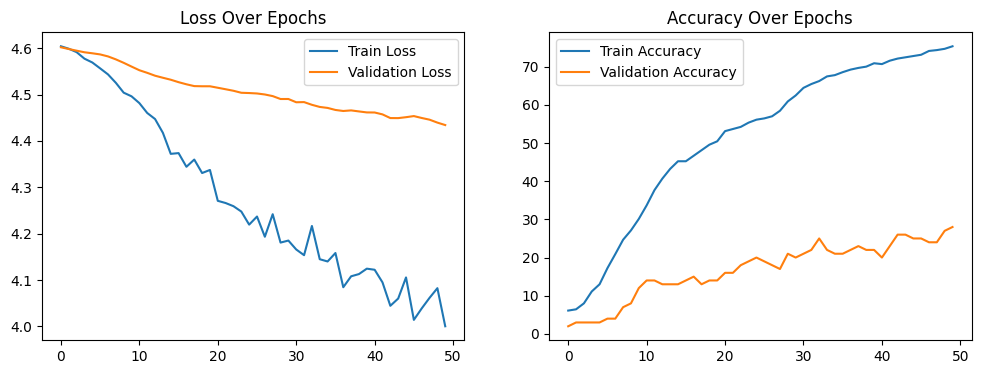

In [14]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

# Get save path

In [17]:
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'model' in dir_list:
    model_dir_path = os.path.join(path,'model')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

model_path_list = os.listdir(model_dir_path)
timestr = time.strftime("%Y%m%d_%H%M%S")
model_file_name = os.path.join(model_dir_path,timestr) + ".pt"

# Save it

In [18]:
torch.save(net.state_dict(),model_file_name)